<a href="https://colab.research.google.com/github/gnoejh/AIBookGitHub/blob/main/7_problems.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# General Problems

## Introduction to Deep Learning Problems

Deep learning models face numerous challenges during training and deployment. Understanding these problems and their solutions is crucial for building robust and effective neural networks. This chapter explores the most common issues encountered in deep learning and the techniques developed to address them.

### Common Deep Learning Problems Overview

| Problem | Description | Primary Causes | Symptoms | Common Solutions |
|---------|-------------|----------------|----------|------------------|
| **Vanishing Gradient** | Gradients become exponentially small in deep networks | Activation saturation, weight initialization | Slow/no learning in early layers | Skip connections, proper initialization, ReLU |
| **Exploding Gradient** | Gradients become exponentially large | Poor weight initialization, deep networks | Training instability, NaN values | Gradient clipping, proper initialization |
| **Overfitting** | Model memorizes training data | High model complexity, insufficient data | High training accuracy, poor validation | Dropout, regularization, data augmentation |
| **Underfitting** | Model too simple to capture patterns | Low model complexity, insufficient training | Poor performance on both train/validation | Increase capacity, more training |
| **Internal Covariate Shift** | Distribution of layer inputs changes during training | Weight updates affect input distributions | Slow convergence, training instability | Batch Normalization, Layer Normalization |
| **Dead Neurons** | Neurons always output zero | ReLU saturation, large negative biases | Reduced model capacity, poor learning | Leaky ReLU, proper initialization |
| **Mode Collapse** | Generator produces limited variety (GANs) | Training dynamics, loss function design | Lack of diversity in generated samples | Modified losses, training techniques |
| **Catastrophic Forgetting** | Model forgets previous tasks when learning new ones | Weight overwriting, shared parameters | Performance drop on old tasks | Elastic Weight Consolidation, rehearsal |

### Problem Categories

Deep learning problems can be broadly categorized into:

1. **Training Dynamics Issues**: Vanishing/exploding gradients, slow convergence
2. **Generalization Problems**: Overfitting, underfitting, distribution shift
3. **Architecture-Specific Issues**: Dead neurons, internal covariate shift
4. **Task-Specific Challenges**: Mode collapse, catastrophic forgetting

Understanding these categories helps in selecting appropriate solutions and designing robust architectures.

## Gradient-Related Problems

### Vanishing Gradient Problem

The vanishing gradient problem occurs when gradients become exponentially smaller as they propagate backwards through deep networks, making it difficult for early layers to learn effectively.

#### Mathematical Foundation
In deep networks with $L$ layers, the gradient of the loss with respect to weights in layer $l$ involves the product:
$$\frac{\partial L}{\partial W^{(l)}} = \frac{\partial L}{\partial z^{(L)}} \prod_{i=l+1}^{L} \frac{\partial z^{(i)}}{\partial z^{(i-1)}}$$

When activation derivatives are small (e.g., sigmoid: $\sigma'(x) \leq 0.25$), this product can become vanishingly small.

#### Causes
- **Activation Function Choice**: Sigmoid and tanh functions saturate, leading to small gradients
- **Weight Initialization**: Poor initialization can lead to activations in saturation regions
- **Network Depth**: Deeper networks compound the gradient decay problem

#### Symptoms
- Early layers learn very slowly or not at all
- Training loss plateaus despite adequate model capacity
- Gradient norms decrease significantly in earlier layers

#### Solutions
1. **Better Activation Functions**: ReLU and variants avoid saturation
2. **Skip Connections**: Allow gradients to flow directly to earlier layers
3. **Proper Weight Initialization**: Xavier/He initialization
4. **Batch Normalization**: Maintains activation distributions
5. **LSTM/GRU**: Gating mechanisms in recurrent networks

### Exploding Gradient Problem

The exploding gradient problem occurs when gradients become exponentially larger during backpropagation, leading to unstable training.

#### Causes
- **Poor Weight Initialization**: Weights too large
- **Deep Networks**: Gradients accumulate and grow exponentially
- **Recurrent Networks**: Gradients can explode over time steps

#### Symptoms
- Training loss oscillates wildly or increases suddenly
- Weight updates become very large
- NaN or infinity values appear in gradients
- Model performance becomes unpredictable

#### Solutions
1. **Gradient Clipping**: Limit gradient magnitude
   ```python
   torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
   ```
2. **Proper Weight Initialization**: Use appropriate initialization schemes
3. **Learning Rate Scheduling**: Start with smaller learning rates
4. **Regularization**: L1/L2 regularization can help control weights

## Normalization and Distribution Problems

### Internal Covariate Shift

Internal covariate shift refers to the change in the distribution of network activations due to the change in network parameters during training.

#### Problem Description
As the parameters of the previous layers change during training, the distribution of inputs to each layer shifts, making training slower and requiring careful parameter initialization.

#### Mathematical Insight
For a layer receiving input $x$, if the distribution of $x$ changes during training, the layer must continuously adapt to these changes, slowing down learning.

#### Symptoms
- Slow convergence during training
- Sensitivity to initialization and learning rates
- Training instability in deep networks

#### Solutions
1. **Batch Normalization**: Normalizes layer inputs to have zero mean and unit variance
   $$BN(x_i) = \gamma \frac{x_i - \mu_B}{\sqrt{\sigma_B^2 + \epsilon}} + \beta$$
2. **Layer Normalization**: Normalizes across features instead of batch
3. **Group Normalization**: Normalizes within groups of channels

### Dead Neuron Problem

Dead neurons are neurons that always output zero for any input, effectively removing them from the network.

#### Causes
- **ReLU Activation**: Neurons with large negative bias never activate
- **Large Learning Rates**: Can push neurons into permanent negative territory
- **Poor Initialization**: Starting with negative biases

#### Symptoms
- Reduced effective network capacity
- Plateauing training performance
- Large portions of network become inactive

#### Solutions
1. **Leaky ReLU**: Allows small negative values
   $$f(x) = \max(0.01x, x)$$
2. **ELU (Exponential Linear Unit)**: Smooth function with negative saturation
3. **Proper Initialization**: Initialize biases to small positive values
4. **Learning Rate Management**: Use appropriate learning rates

## Architectural Solutions and Layer Innovations

### Skip Connections and Residual Learning

Skip connections, popularized by ResNet, directly address the vanishing gradient problem by providing shortcuts for gradient flow.

#### Mathematical Foundation
Instead of learning a function $H(x)$, residual blocks learn:
$$H(x) = F(x) + x$$
where $F(x)$ is the residual function.

#### Benefits
- **Gradient Flow**: Gradients can flow directly through skip connections
- **Easier Optimization**: Identity shortcuts make optimization easier
- **Deep Network Training**: Enables training of very deep networks (100+ layers)

#### Applications
- **ResNet**: Convolutional skip connections
- **DenseNet**: Dense connections between all layers
- **Transformer**: Skip connections around attention and feed-forward layers

### Normalization Techniques

Different normalization techniques address various aspects of training instability.

#### Batch Normalization
- **Purpose**: Reduces internal covariate shift
- **Operation**: Normalizes over batch dimension
- **Benefits**: Faster convergence, less sensitive to initialization
- **Limitations**: Dependent on batch size, problematic for small batches

#### Layer Normalization
- **Purpose**: Alternative to batch norm for sequential data
- **Operation**: Normalizes over feature dimension
- **Benefits**: Independent of batch size, works well with RNNs
- **Applications**: Transformers, RNNs

#### Group Normalization
- **Purpose**: Compromise between batch and layer normalization
- **Operation**: Normalizes within groups of channels
- **Benefits**: Stable across different batch sizes
- **Applications**: Computer vision tasks with small batches

### Regularization Techniques

#### Dropout
- **Purpose**: Prevents overfitting by randomly setting neurons to zero
- **Benefits**: Reduces co-adaptation, improves generalization
- **Variants**: 
  - Standard Dropout: Random neuron removal
  - DropConnect: Random connection removal
  - Spatial Dropout: Channel-wise dropout for CNNs

#### Weight Decay (L2 Regularization)
- **Purpose**: Prevents large weights that can cause overfitting
- **Mathematical Form**: Add $\lambda \sum w_i^2$ to loss function
- **Benefits**: Smoother decision boundaries, better generalization

### Activation Function Evolution

#### Traditional Problems with Sigmoid/Tanh
- Vanishing gradients due to saturation
- Not zero-centered (sigmoid)
- Computationally expensive

#### ReLU Family
1. **ReLU**: $f(x) = \max(0, x)$
   - Pros: No vanishing gradient, computationally efficient
   - Cons: Dead neuron problem

2. **Leaky ReLU**: $f(x) = \max(0.01x, x)$
   - Pros: Fixes dead neuron problem
   - Cons: Introduces hyperparameter

3. **ELU**: Smooth function with negative saturation
   - Pros: Smooth, zero-centered, robust to noise
   - Cons: Computationally more expensive

4. **Swish/SiLU**: $f(x) = x \cdot \sigma(x)$
   - Pros: Smooth, self-gated, good empirical performance
   - Cons: More computationally expensive

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import DataLoader, TensorDataset

# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Generate sample data
def generate_data(n_samples=1000):
    X = torch.randn(n_samples, 10)
    y = torch.sum(X[:, :3], dim=1) + 0.1 * torch.randn(n_samples)
    return X, y.unsqueeze(1)

X, y = generate_data()
dataset = TensorDataset(X, y)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

print("Data generated successfully!")
print(f"Input shape: {X.shape}")
print(f"Target shape: {y.shape}")

Data generated successfully!
Input shape: torch.Size([1000, 10])
Target shape: torch.Size([1000, 1])


### Practical Example 1: Demonstrating Vanishing Gradient Problem

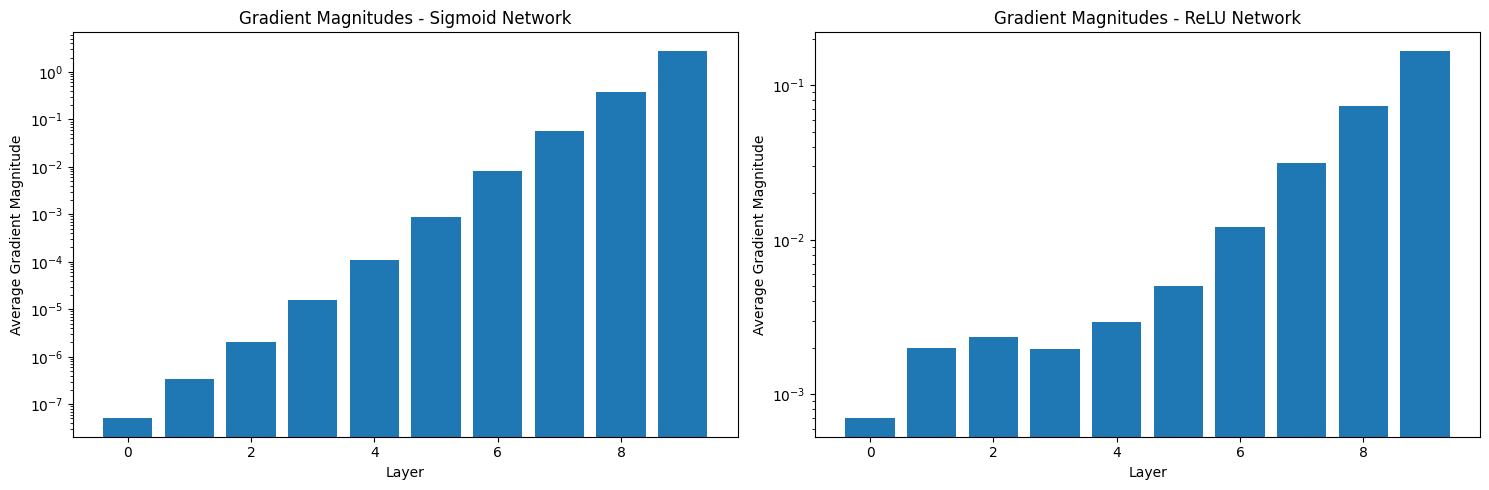

Vanishing Gradient Analysis:
Sigmoid model - First layer avg gradient: 0.000000
Sigmoid model - Last layer avg gradient: 2.791139
ReLU model - First layer avg gradient: 0.000700
ReLU model - Last layer avg gradient: 0.167585


In [5]:
# Deep network with sigmoid activations (prone to vanishing gradients)
class DeepSigmoidNet(nn.Module):
    def __init__(self, input_size=10, hidden_size=50, num_layers=10):
        super().__init__()
        layers = []
        layers.append(nn.Linear(input_size, hidden_size))
        layers.append(nn.Sigmoid())
        
        for _ in range(num_layers - 2):
            layers.append(nn.Linear(hidden_size, hidden_size))
            layers.append(nn.Sigmoid())
        
        layers.append(nn.Linear(hidden_size, 1))
        self.network = nn.Sequential(*layers)
        
    def forward(self, x):
        return self.network(x)

# Deep network with ReLU activations (solution)
class DeepReLUNet(nn.Module):
    def __init__(self, input_size=10, hidden_size=50, num_layers=10):
        super().__init__()
        layers = []
        layers.append(nn.Linear(input_size, hidden_size))
        layers.append(nn.ReLU())
        
        for _ in range(num_layers - 2):
            layers.append(nn.Linear(hidden_size, hidden_size))
            layers.append(nn.ReLU())
        
        layers.append(nn.Linear(hidden_size, 1))
        self.network = nn.Sequential(*layers)
        
    def forward(self, x):
        return self.network(x)

def analyze_gradients(model, data_loader, criterion):
    """Analyze gradient magnitudes across layers"""
    model.train()
    gradients = {name: [] for name, param in model.named_parameters() if 'weight' in name}
    
    for batch_idx, (data, target) in enumerate(data_loader):
        if batch_idx >= 5:  # Only analyze first 5 batches
            break
            
        optimizer = optim.Adam(model.parameters())
        optimizer.zero_grad()
        
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        
        for name, param in model.named_parameters():
            if 'weight' in name and param.grad is not None:
                gradients[name].append(param.grad.norm().item())
    
    return gradients

# Create models
sigmoid_model = DeepSigmoidNet()
relu_model = DeepReLUNet()

# Analyze gradients
criterion = nn.MSELoss()
sigmoid_grads = analyze_gradients(sigmoid_model, dataloader, criterion)
relu_grads = analyze_gradients(relu_model, dataloader, criterion)

# Visualize gradient magnitudes
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot sigmoid gradients
layer_names = list(sigmoid_grads.keys())
avg_grads_sigmoid = [np.mean(sigmoid_grads[name]) for name in layer_names]
ax1.bar(range(len(layer_names)), avg_grads_sigmoid)
ax1.set_title('Gradient Magnitudes - Sigmoid Network')
ax1.set_xlabel('Layer')
ax1.set_ylabel('Average Gradient Magnitude')
ax1.set_yscale('log')

# Plot ReLU gradients
avg_grads_relu = [np.mean(relu_grads[name]) for name in layer_names]
ax2.bar(range(len(layer_names)), avg_grads_relu)
ax2.set_title('Gradient Magnitudes - ReLU Network')
ax2.set_xlabel('Layer')
ax2.set_ylabel('Average Gradient Magnitude')
ax2.set_yscale('log')

plt.tight_layout()
plt.show()

print("Vanishing Gradient Analysis:")
print(f"Sigmoid model - First layer avg gradient: {avg_grads_sigmoid[0]:.6f}")
print(f"Sigmoid model - Last layer avg gradient: {avg_grads_sigmoid[-1]:.6f}")
print(f"ReLU model - First layer avg gradient: {avg_grads_relu[0]:.6f}")
print(f"ReLU model - Last layer avg gradient: {avg_grads_relu[-1]:.6f}")

### Practical Example 2: Batch Normalization Benefits

Training Simple Network (without Batch Norm):
Epoch 0, Loss: 0.6929
Epoch 10, Loss: 0.0109
Epoch 20, Loss: 0.0121
Epoch 30, Loss: 0.0107
Epoch 40, Loss: 0.0199

Training Batch Norm Network:
Epoch 0, Loss: 0.4743
Epoch 10, Loss: 0.1425
Epoch 20, Loss: 0.1200
Epoch 30, Loss: 0.1996
Epoch 40, Loss: 0.1901


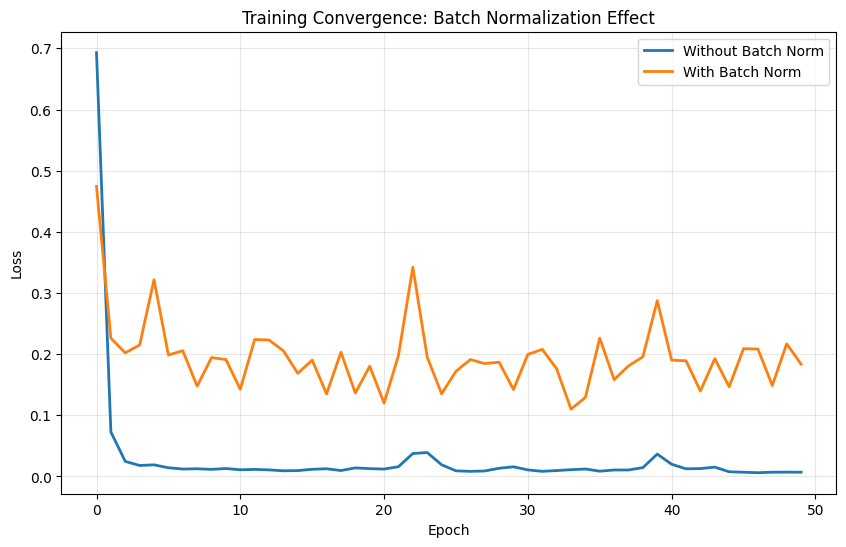


Final Loss - Simple Net: 0.0069
Final Loss - Batch Norm Net: 0.1838
Improvement: -2548.2%


In [6]:
# Network without Batch Normalization
class SimpleNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(10, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
    
    def forward(self, x):
        return self.layers(x)

# Network with Batch Normalization
class BatchNormNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(10, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
    
    def forward(self, x):
        return self.layers(x)

def train_model(model, data_loader, epochs=50):
    """Train model and return loss history"""
    model.train()
    optimizer = optim.Adam(model.parameters(), lr=0.01)
    criterion = nn.MSELoss()
    losses = []
    
    for epoch in range(epochs):
        epoch_loss = 0
        for data, target in data_loader:
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        
        losses.append(epoch_loss / len(data_loader))
        if epoch % 10 == 0:
            print(f'Epoch {epoch}, Loss: {losses[-1]:.4f}')
    
    return losses

# Train both models
print("Training Simple Network (without Batch Norm):")
simple_model = SimpleNet()
simple_losses = train_model(simple_model, dataloader)

print("\nTraining Batch Norm Network:")
bn_model = BatchNormNet()
bn_losses = train_model(bn_model, dataloader)

# Plot training curves
plt.figure(figsize=(10, 6))
plt.plot(simple_losses, label='Without Batch Norm', linewidth=2)
plt.plot(bn_losses, label='With Batch Norm', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Convergence: Batch Normalization Effect')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"\nFinal Loss - Simple Net: {simple_losses[-1]:.4f}")
print(f"Final Loss - Batch Norm Net: {bn_losses[-1]:.4f}")
print(f"Improvement: {((simple_losses[-1] - bn_losses[-1]) / simple_losses[-1] * 100):.1f}%")

### Practical Example 3: Dropout for Overfitting Prevention

Training without Dropout:
Epoch 0, Train Loss: 30.4956, Val Loss: 20.7331
Epoch 20, Train Loss: 0.8289, Val Loss: 5.1780
Epoch 40, Train Loss: 0.0234, Val Loss: 4.0359
Epoch 60, Train Loss: 0.0013, Val Loss: 3.8630
Epoch 80, Train Loss: 0.0002, Val Loss: 3.8340

Training with Dropout:
Epoch 0, Train Loss: 32.6362, Val Loss: 23.9244
Epoch 20, Train Loss: 3.7137, Val Loss: 7.1667
Epoch 40, Train Loss: 1.9391, Val Loss: 4.9797
Epoch 60, Train Loss: 1.6735, Val Loss: 4.1229
Epoch 80, Train Loss: 1.7538, Val Loss: 4.1054


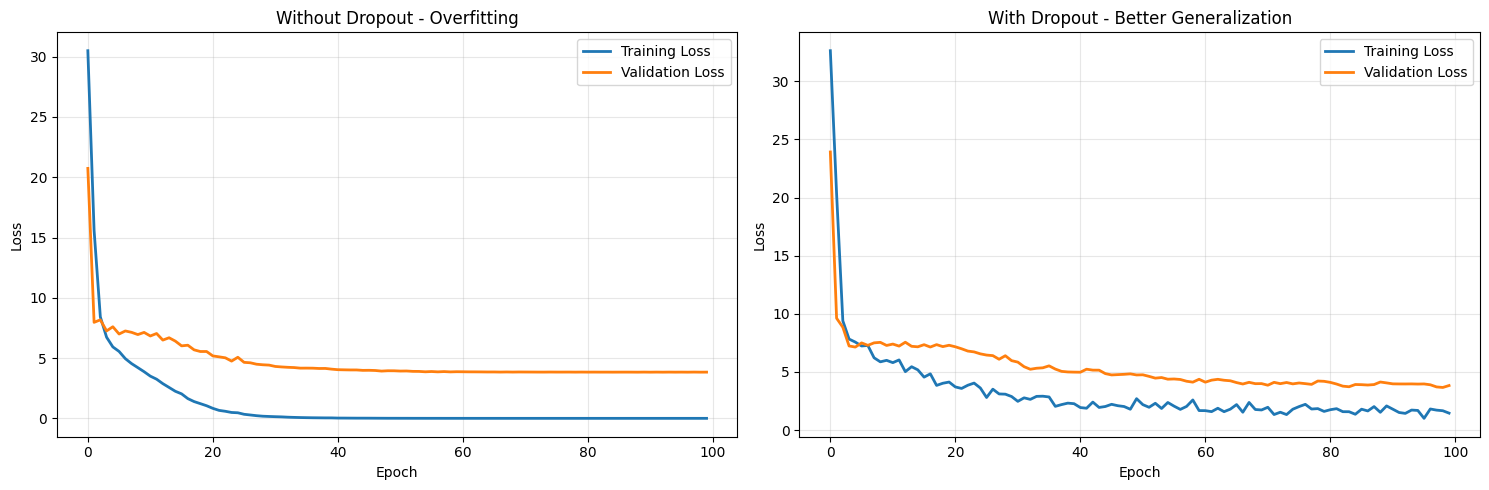


Final Results:
No Dropout - Train: 0.0003, Val: 3.8337
With Dropout - Train: 1.4590, Val: 3.8332
Generalization Gap Reduction: 0.0%


In [7]:
# Create a more complex dataset to demonstrate overfitting
def generate_complex_data(n_samples=200):
    """Generate a small dataset where overfitting is likely"""
    X = torch.randn(n_samples, 20)
    # Complex non-linear relationship
    y = (torch.sum(X[:, :5]**2, dim=1) + 
         0.5 * torch.sum(X[:, 5:10], dim=1) + 
         0.1 * torch.randn(n_samples))
    return X, y.unsqueeze(1)

# Generate small training set (prone to overfitting)
X_train, y_train = generate_complex_data(200)
X_val, y_val = generate_complex_data(100)

train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

# Network without Dropout (prone to overfitting)
class OverfittingNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(20, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )
    
    def forward(self, x):
        return self.layers(x)

# Network with Dropout
class DropoutNet(nn.Module):
    def __init__(self, dropout_rate=0.3):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(20, 128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(64, 1)
        )
    
    def forward(self, x):
        return self.layers(x)

def train_with_validation(model, train_loader, val_loader, epochs=100):
    """Train model and track both training and validation losses"""
    model.train()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.MSELoss()
    
    train_losses, val_losses = [], []
    
    for epoch in range(epochs):
        # Training
        model.train()
        train_loss = 0
        for data, target in train_loader:
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        
        # Validation
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for data, target in val_loader:
                output = model(data)
                loss = criterion(output, target)
                val_loss += loss.item()
        
        train_losses.append(train_loss / len(train_loader))
        val_losses.append(val_loss / len(val_loader))
        
        if epoch % 20 == 0:
            print(f'Epoch {epoch}, Train Loss: {train_losses[-1]:.4f}, Val Loss: {val_losses[-1]:.4f}')
    
    return train_losses, val_losses

# Train both models
print("Training without Dropout:")
overfitting_model = OverfittingNet()
train_losses_no_dropout, val_losses_no_dropout = train_with_validation(
    overfitting_model, train_loader, val_loader)

print("\nTraining with Dropout:")
dropout_model = DropoutNet()
train_losses_dropout, val_losses_dropout = train_with_validation(
    dropout_model, train_loader, val_loader)

# Plot results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Without Dropout
ax1.plot(train_losses_no_dropout, label='Training Loss', linewidth=2)
ax1.plot(val_losses_no_dropout, label='Validation Loss', linewidth=2)
ax1.set_title('Without Dropout - Overfitting')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# With Dropout
ax2.plot(train_losses_dropout, label='Training Loss', linewidth=2)
ax2.plot(val_losses_dropout, label='Validation Loss', linewidth=2)
ax2.set_title('With Dropout - Better Generalization')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nFinal Results:")
print(f"No Dropout - Train: {train_losses_no_dropout[-1]:.4f}, Val: {val_losses_no_dropout[-1]:.4f}")
print(f"With Dropout - Train: {train_losses_dropout[-1]:.4f}, Val: {val_losses_dropout[-1]:.4f}")
print(f"Generalization Gap Reduction: {((val_losses_no_dropout[-1] - val_losses_dropout[-1]) / val_losses_no_dropout[-1] * 100):.1f}%")

## Summary and Best Practices

### Problem-Solution Mapping

| Problem Category | Specific Issues | Recommended Solutions | Implementation Priority |
|------------------|-----------------|----------------------|------------------------|
| **Gradient Flow** | Vanishing gradients | ReLU activations, Skip connections, Proper initialization | High |
| | Exploding gradients | Gradient clipping, Learning rate scheduling | High |
| **Training Stability** | Internal covariate shift | Batch Normalization, Layer Normalization | High |
| | Dead neurons | Leaky ReLU, ELU, Proper initialization | Medium |
| **Generalization** | Overfitting | Dropout, Weight decay, Data augmentation | High |
| | Underfitting | Increase model capacity, Reduce regularization | Medium |
| **Optimization** | Slow convergence | Adam optimizer, Learning rate scheduling | Medium |
| | Poor initialization | Xavier/He initialization | High |

### Modern Architecture Guidelines

1. **Activation Functions**: Use ReLU or its variants (Leaky ReLU, ELU, Swish)
2. **Normalization**: Include Batch Normalization after each linear layer
3. **Regularization**: Apply Dropout (0.2-0.5) in fully connected layers
4. **Skip Connections**: Use residual connections in deep networks
5. **Initialization**: Use He initialization for ReLU, Xavier for other activations
6. **Optimization**: Start with Adam optimizer and cosine learning rate scheduling

### Evolution of Deep Learning Solutions

The development of deep learning has been largely driven by identifying and solving training problems:

1. **2006-2010**: Recognition of vanishing gradient problems
2. **2010-2012**: Introduction of ReLU activations
3. **2014-2015**: Batch Normalization and Dropout widespread adoption
4. **2015-2016**: Skip connections and residual learning (ResNet)
5. **2017+**: Advanced normalization techniques, attention mechanisms

### Future Directions

Ongoing research continues to address remaining challenges:
- **Training Efficiency**: Neural Architecture Search, efficient training methods
- **Robustness**: Adversarial training, uncertainty quantification
- **Scalability**: Model parallelism, gradient compression
- **Interpretability**: Understanding what networks learn and why they fail

Understanding these fundamental problems and their solutions is crucial for designing effective deep learning systems and debugging training issues when they arise.

## Fitting

Optimal fitting refers to the balance between underfitting and overfitting in a model. It is crucial to achieve a model that generalizes well to new data.



### Underfitting

Underfitting occurs when a model is too simple to capture the underlying patterns in the data. This results in poor performance on both the training and validation datasets.

#### Characteristics of Underfitting:
- High bias
- Low variance
- Poor performance on training data
- Poor performance on validation data

#### Solutions to Underfitting:
- Increase model complexity
- Use more features
- Reduce regularization

### Optimal Fitting

Optimal fitting is achieved when a model performs well on both training and validation datasets, indicating good generalization.

#### Characteristics of Optimal Fitting:
- Balanced bias and variance
- Good performance on training data
- Good performance on validation data

#### Solutions to Achieve Optimal Fitting:
- Use cross-validation to tune hyperparameters
- Use ensemble methods
- Regularly evaluate model performance on validation data

### Overfitting

Overfitting occurs when the model learns not only the underlying patterns but also the noise in the training data, leading to poor generalization on unseen data.

#### Characteristics of Overfitting:
- Low bias
- High variance
- Excellent performance on training data
- Poor performance on validation data

#### Solutions to Overfitting:
- Use regularization techniques such as L1/L2 regularization
- Implement dropout
- Increase training data size
- Use early stopping

Underfit model  : Train MSE = 3.3061, Val MSE = 56.6842
Optimal model   : Train MSE = 0.2309, Val MSE = 4.4494
Overfit model   : Train MSE = 0.1435, Val MSE = 7.9622


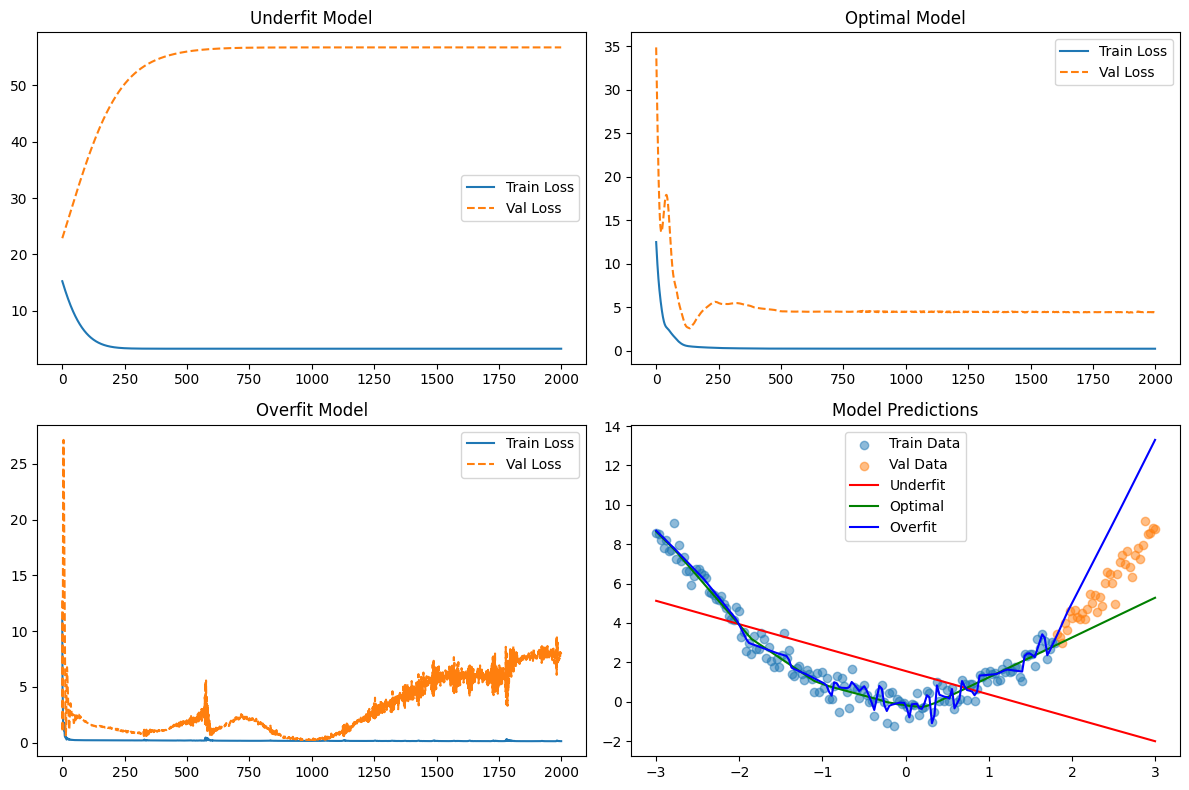

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

# ---------------------------
# 1) Create synthetic dataset
# ---------------------------

torch.manual_seed(10)
N = 200
X = torch.linspace(-3, 3, N).unsqueeze(1)  # Shape: [N, 1]
y_true = X**2
noise = 0.5 * torch.randn_like(X)         
y = y_true + noise

train_size = int(0.8 * N)
X_train, X_val = X[:train_size], X[train_size:]
y_train, y_val = y[:train_size], y[train_size:]


# -------------------------------
# 2) Define various model classes
# -------------------------------

class UnderfitNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(1, 1)

    def forward(self, x):
        return self.linear(x)

class OptimalNet(nn.Module):
    def __init__(self, hidden_dim=16):
        super().__init__()
        self.fc1 = nn.Linear(1, hidden_dim)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

class OverfitNet(nn.Module):
    def __init__(self, hidden_dim=128):
        super().__init__()
        self.fc1 = nn.Linear(1, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, hidden_dim)
        self.fc4 = nn.Linear(hidden_dim, 1)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.relu(self.fc3(x))
        x = self.fc4(x)
        return x


# ----------------------
# 3) Training function
# ----------------------

def train_model(model, X_tr, y_tr, X_vl, y_vl, epochs=1000, lr=1e-2):
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    train_losses = []
    val_losses = []
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        y_pred = model(X_tr)
        loss = criterion(y_pred, y_tr)
        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            y_val_pred = model(X_vl)
            val_loss = criterion(y_val_pred, y_vl)

        train_losses.append(loss.item())
        val_losses.append(val_loss.item())

    return train_losses, val_losses

def evaluate_model(model, X_data, y_data):
    model.eval()
    with torch.no_grad():
        y_pred = model(X_data)
        mse = nn.functional.mse_loss(y_pred, y_data).item()
    return mse


# ------------------------
# 4) Train the three models
# ------------------------

model_underfit = UnderfitNet()
model_optimal = OptimalNet()
model_overfit = OverfitNet()

epochs = 2000
uf_train, uf_val = train_model(model_underfit, X_train, y_train, X_val, y_val, epochs)
opt_train, opt_val = train_model(model_optimal, X_train, y_train, X_val, y_val, epochs)
ov_train, ov_val = train_model(model_overfit, X_train, y_train, X_val, y_val, epochs)

print("Underfit model  : Train MSE = {:.4f}, Val MSE = {:.4f}"
      .format(evaluate_model(model_underfit, X_train, y_train),
              evaluate_model(model_underfit, X_val, y_val)))
print("Optimal model   : Train MSE = {:.4f}, Val MSE = {:.4f}"
      .format(evaluate_model(model_optimal, X_train, y_train),
              evaluate_model(model_optimal, X_val, y_val)))
print("Overfit model   : Train MSE = {:.4f}, Val MSE = {:.4f}"
      .format(evaluate_model(model_overfit, X_train, y_train),
              evaluate_model(model_overfit, X_val, y_val)))


# -----------------------------
# 5) Plot separate loss subplots
# -----------------------------
fig, axs = plt.subplots(2, 2, figsize=(12, 8))

# Underfit losses
axs[0, 0].plot(uf_train, label='Train Loss')
axs[0, 0].plot(uf_val, label='Val Loss', linestyle='--')
axs[0, 0].set_title('Underfit Model')
axs[0, 0].legend()

# Optimal losses
axs[0, 1].plot(opt_train, label='Train Loss')
axs[0, 1].plot(opt_val, label='Val Loss', linestyle='--')
axs[0, 1].set_title('Optimal Model')
axs[0, 1].legend()

# Overfit losses
axs[1, 0].plot(ov_train, label='Train Loss')
axs[1, 0].plot(ov_val, label='Val Loss', linestyle='--')
axs[1, 0].set_title('Overfit Model')
axs[1, 0].legend()

# ------------------
# 6) Plot predictions
# ------------------
X_plot = torch.linspace(-3, 3, 200).unsqueeze(1)
with torch.no_grad():
    y_uf = model_underfit(X_plot)
    y_opt = model_optimal(X_plot)
    y_ov = model_overfit(X_plot)

axs[1, 1].scatter(X_train.numpy(), y_train.numpy(), label='Train Data', alpha=0.5)
axs[1, 1].scatter(X_val.numpy(), y_val.numpy(), label='Val Data', alpha=0.5)
axs[1, 1].plot(X_plot.numpy(), y_uf.numpy(), label='Underfit', color='r')
axs[1, 1].plot(X_plot.numpy(), y_opt.numpy(), label='Optimal', color='g')
axs[1, 1].plot(X_plot.numpy(), y_ov.numpy(), label='Overfit', color='b')
axs[1, 1].legend()
axs[1, 1].set_title('Model Predictions')

plt.tight_layout()
plt.show()


## Gradient Exploding

The gradient exploding problem occurs when gradients become very large during backpropagation, causing the weights to update excessively and destabilize the training process. This is another common issue in deep neural networks.

#### Causes of Gradient Exploding:
- Poor initialization of weights
- High learning rates
- Deep networks with many layers

#### Solutions to Gradient Exploding:
- Use gradient clipping to limit the size of gradients
- Use proper weight initialization techniques
- Use architectures like residual networks (ResNets)

In [9]:
import torch
import torch.nn as nn
import torch.optim as optim

# For reproducibility
torch.manual_seed(100)

# ----------------------
# 1) Define LSTM model
# ----------------------
class LSTMClassifier(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super(LSTMClassifier, self).__init__()
        self.hidden_size = hidden_size
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, num_classes)
        
    def forward(self, x):
        # x shape: (batch_size, seq_length, input_size)
        out, (h_n, c_n) = self.lstm(x)
        # Take the output at the final time step
        out = out[:, -1, :]  # shape: (batch_size, hidden_size)
        out = self.fc(out)
        return out

# ----------------------------
# 2) Generate random long data
# ----------------------------
sequence_length = 200   # Large sequence length to exacerbate exploding grads
batch_size = 10
input_size = 64
hidden_size = 128       # Large hidden layer
num_classes = 2

X = torch.randn(batch_size, sequence_length, input_size)  # Random input
y = torch.randint(0, num_classes, (batch_size,))          # Random labels

# -----------------------
# 3) Instantiate the model
# -----------------------
model = LSTMClassifier(input_size, hidden_size, num_classes)
criterion = nn.CrossEntropyLoss()

# NOTE: Extremely large learning rate to induce gradient explosion
learning_rate = 10.0
optimizer = optim.SGD(model.parameters(), lr=learning_rate)

# -----------------
# 4) Training loop
# -----------------
num_epochs = 10
grad_norm_history = []

for epoch in range(num_epochs):
    optimizer.zero_grad()
    outputs = model(X)
    loss = criterion(outputs, y)
    
    loss.backward()
    
    # Calculate and record the total gradient norm
    total_norm = 0.0
    for p in model.parameters():
        if p.grad is not None:
            param_norm = p.grad.data.norm(2)
            total_norm += param_norm.item() ** 2
    total_norm = total_norm ** 0.5
    grad_norm_history.append(total_norm)

    optimizer.step()

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Loss: {loss.item():.4f} | Grad Norm: {total_norm:.4f}")

# --------------------------
# 5) Check final observations
# --------------------------
# Over several epochs, you may see the gradient norm become very large
# or even the loss jump to NaN if it overflows.


Epoch [1/10] Loss: 0.6930 | Grad Norm: 0.4069
Epoch [2/10] Loss: 0.1307 | Grad Norm: 0.5146
Epoch [3/10] Loss: 0.6485 | Grad Norm: 2.7655
Epoch [4/10] Loss: 6.7665 | Grad Norm: 3.8049
Epoch [5/10] Loss: 14.8679 | Grad Norm: 5.8872
Epoch [6/10] Loss: 5.1739 | Grad Norm: 7.1485
Epoch [7/10] Loss: 7.6690 | Grad Norm: 10.8009
Epoch [8/10] Loss: 5.0468 | Grad Norm: 9.4409
Epoch [9/10] Loss: 0.0000 | Grad Norm: 0.0000
Epoch [10/10] Loss: 0.0000 | Grad Norm: 0.0000


## Vanishing Gradient

The vanishing gradient problem occurs when gradients become very small during backpropagation, causing the weights to update very slowly and hindering the training process. This is a common issue in deep neural networks.

#### Causes of Vanishing Gradient:
- Poor initialization of weights
- Activation functions like sigmoid or tanh
- Deep networks with many layers

#### Solutions to Vanishing Gradient:
- Use ReLU or its variants as activation functions
- Use proper weight initialization techniques
- Use architectures like LSTM or GRU for recurrent neural networks

### Regularization Techniques

Regularization techniques are used to prevent overfitting and improve the generalization of the model. Some common regularization techniques include:

### L1 Regularization (Lasso)

L1 regularization adds a penalty equal to the absolute value of the magnitude of coefficients. It can lead to sparse models where some feature weights are exactly zero.

### L2 Regularization (Ridge)

L2 regularization adds a penalty equal to the square of the magnitude of coefficients. It encourages smaller weights but does not lead to sparse models.

### Dropout

Dropout is a regularization technique where randomly selected neurons are ignored during training. This prevents the model from becoming too reliant on any particular neuron and promotes the development of redundant representations.

### Early Stopping

Early stopping involves monitoring the model's performance on a validation set and stopping training when performance stops improving. This prevents the model from overfitting to the training data.

In [10]:
import torch
import torch.nn as nn
import torch.optim as optim

# -----------------------
# 1) Set seeds for reproducibility
# -----------------------
torch.manual_seed(0)

# -----------------------
# 2) Generate random data
# -----------------------
N = 256        # Number of samples
input_dim = 20 # Input feature dimension
num_classes = 2

X = torch.randn(N, input_dim)                # Random features
y = torch.randint(0, num_classes, (N,))      # Random labels (binary classification)

# --------------------------------------------
# 3) Define a deep network with Sigmoid layers
# --------------------------------------------
class DeepSigmoidNet(nn.Module):
    def __init__(self, input_dim=20, hidden_dim=64, depth=10, output_dim=2):
        """
        :param input_dim: dimension of the input
        :param hidden_dim: number of units per hidden layer
        :param depth: number of hidden layers
        :param output_dim: dimension of the output (for classification, = num_classes)
        """
        super().__init__()
        layers = []
        in_dim = input_dim
        for _ in range(depth):
            layers.append(nn.Linear(in_dim, hidden_dim))
            layers.append(nn.Sigmoid())
            in_dim = hidden_dim

        layers.append(nn.Linear(in_dim, output_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

# --------------------
# 4) Instantiate model
# --------------------
model = DeepSigmoidNet(input_dim=20, hidden_dim=64, depth=10, output_dim=num_classes)
criterion = nn.CrossEntropyLoss()

# Small enough LR to avoid exploding gradients, but deep Sigmoid can vanish
optimizer = optim.SGD(model.parameters(), lr=0.01)

# -----------------
# 5) Training loop
# -----------------
num_epochs = 30
for epoch in range(num_epochs):
    optimizer.zero_grad()

    # Forward pass
    outputs = model(X)
    loss = criterion(outputs, y)

    # Backward pass
    loss.backward()

    # Calculate total gradient norm
    total_grad_norm = 0.0
    for p in model.parameters():
        if p.grad is not None:
            param_norm = p.grad.data.norm(2)
            total_grad_norm += param_norm.item()**2
    total_grad_norm = total_grad_norm**0.5

    # Update parameters
    optimizer.step()

    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {loss.item():.4f}, Grad Norm: {total_grad_norm:.4e}")


Epoch 1/30, Loss: 0.6935, Grad Norm: 8.9634e-02
Epoch 2/30, Loss: 0.6934, Grad Norm: 8.1789e-02
Epoch 3/30, Loss: 0.6933, Grad Norm: 7.4630e-02
Epoch 4/30, Loss: 0.6933, Grad Norm: 6.8097e-02
Epoch 5/30, Loss: 0.6932, Grad Norm: 6.2136e-02
Epoch 6/30, Loss: 0.6932, Grad Norm: 5.6697e-02
Epoch 7/30, Loss: 0.6932, Grad Norm: 5.1734e-02
Epoch 8/30, Loss: 0.6932, Grad Norm: 4.7205e-02
Epoch 9/30, Loss: 0.6931, Grad Norm: 4.3072e-02
Epoch 10/30, Loss: 0.6931, Grad Norm: 3.9302e-02
Epoch 11/30, Loss: 0.6931, Grad Norm: 3.5861e-02
Epoch 12/30, Loss: 0.6931, Grad Norm: 3.2722e-02
Epoch 13/30, Loss: 0.6931, Grad Norm: 2.9857e-02
Epoch 14/30, Loss: 0.6931, Grad Norm: 2.7244e-02
Epoch 15/30, Loss: 0.6931, Grad Norm: 2.4859e-02
Epoch 16/30, Loss: 0.6931, Grad Norm: 2.2683e-02
Epoch 17/30, Loss: 0.6930, Grad Norm: 2.0697e-02
Epoch 18/30, Loss: 0.6930, Grad Norm: 1.8886e-02
Epoch 19/30, Loss: 0.6930, Grad Norm: 1.7232e-02
Epoch 20/30, Loss: 0.6930, Grad Norm: 1.5724e-02
Epoch 21/30, Loss: 0.6930, Gr